# Chebyshev Policies and the Mountain Car Problem: Reinforcement Learning for Low-dimensional Control Tasks
## Chebyshev ARS @ Pendulum Environment

Does good performance carry over to a more complicated problem setting?  
We utilize the Gymnasium Pendulum environment, which, again, resembles a typical low-dimensional control task but which's observation space has one more dimension.  
We use Chebyshev approximators with ARS instead of REINFORCE in order to mitigate deficiencies of the algorithm for this more complex problem setting.  

Version 1.0   
Date: 2025-11-06  
Current version: hannes.unger@fh-salzburg.ac.at    

## Pendulum Environment

[https://gymnasium.farama.org/environments/classic_control/pendulum/](https://gymnasium.farama.org/environments/classic_control/pendulum/)

<img width="300" alt="image" src="https://gymnasium.farama.org/_images/pendulum.gif">

This environment is part of the Classic Control environments which contains general information about the environment.  

- Action Space: Box(-2.0, 2.0, (1,), float32)
- Observation Space / State Space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)

## Description

The inverted pendulum swingup problem is based on the classic problem in control theory.  
The system consists of a pendulum attached at one end to a fixed point, and the other end being free.  
The pendulum starts in a random position and the goal is to apply torque on the free end to swing it into an upright position,  
with its center of gravity right above the fixed point.   

The diagram below specifies the coordinate system used for the implementation of the pendulum’s dynamic equations.  

<img width="300" alt="image" src="https://gymnasium.farama.org/_images/pendulum.png">

- x-y: cartesian coordinates of the pendulum’s end in meters.  
- theta : angle in radians.  
- tau: torque in N m. Defined as positive counter-clockwise.  

## Observation Space

The observation is a ndarray with shape (3,) representing the x-y coordinates of the pendulum’s free end and its angular velocity.  

| Num | Observation                          | Min  | Max |
| --- |--------------------------------------|------|-----|
| 0   | x = cos(theta)                       | -1.0 | 1.0 |
| 1   | y = sin(theta)                       | -1.0 | 1.0 |
| 2   | Angular Velocity                     | -8.0 | 8.0 |

## Action Space

The action is a ndarray with shape (1,) representing the torque applied to free end of the pendulum.   

## Rewards

The reward function is defined as:

r = -(theta^2 + 0.1 * theta_dt^2 + 0.001 * torque^2)

where theta is the pendulum’s angle normalized between [-pi, pi] (with 0 being in the upright position).  
Based on the above equation, the minimum reward that can be obtained per step is -(pi2 + 0.1 * 82 + 0.001 * 22) = -16.2736044,  
while the maximum reward is zero (pendulum is upright with zero velocity and no torque applied).   

## Starting State

The starting state is a random angle in [-pi, pi] and a random angular velocity in [-1,1].  

## Episode End

The episode truncates at 200 time steps.  

# Imports and Definitions

In [ ]:
import os
import time
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
import torch
from itertools import repeat
from utils import exp_run, plot, parallel
from polyagents import multivariate_polynomial_basis

from pickleshare import PickleShareDB
db = PickleShareDB('./picklesharedb')

tensorboard_log_dir = "./tensorboard_logs/"
os.makedirs(tensorboard_log_dir, exist_ok=True)

%load_ext autoreload
%autoreload 2

2026-01-29 10:20:02.026923: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 10:20:03.101279: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def run_chebyshev_ars_training(args, numcores):
    start = time.time()
    with mp.Pool(processes=numcores) as pool:
        results = pool.map(exp_run.run_sb3_polyagent_training, args)
    print(f'Execution took {time.time()-start:.0f} seconds')
    return results

In [ ]:
def run_chebyshev_ars_evaluation(results, initial_states, numcores, action_space_normalization=True):
    coeffs = [row[2] for row in results]
    pool = parallel.NestablePool(numcores)
    return pool.starmap(exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states_single_coeffs, zip(coeffs, repeat(initial_states), repeat(action_space_normalization)))

In [4]:
def plot_training_reward(log_dir, num_policies, name_prefix, seed, title):
    fig, ax1 = plt.subplots() 
    fig.set_figwidth(18)
    fig.set_figheight(8)
    fig.suptitle(title)

    plot.plot_results(tensorboard_dir=log_dir, num_experiments=num_policies, name_prefix=name_prefix, seed=seed, ax=ax1, title=None)

In [5]:
from collections import defaultdict

def summarize_rewards(results):
    """
    Computes min, mean, and max rewards for each distinct algorithm.
    
    Args:
        results (list): A list of entries, where each entry is of the form:
                        [algorithm_name (str), array (np.ndarray), reward (float)]
    
    Returns:
        dict: A dictionary with algorithm names as keys and a dict of stats:
              {'min': ..., 'mean': ..., 'max': ...}
    """
    rewards_by_algo = defaultdict(list)

    # Collect rewards per algorithm
    for algo, _, reward in results:
        rewards_by_algo[algo].append(reward)

    # Compute stats
    summary = {}
    for algo, rewards in rewards_by_algo.items():
        rewards = np.array(rewards)
        summary[algo] = {
            'min': np.min(rewards),
            'mean': np.mean(rewards),
            'max': np.max(rewards)
        }
    
    return summary

In [6]:
from envs import custom_gymnasium
from gymnasium.envs.registration import register

deterministic_pendulum_env_name = 'DeterministicPendulum-v1'

# Register the environment
register(
    id=f'{deterministic_pendulum_env_name}',
    entry_point='envs.custom_gymnasium:DeterministicPendulumEnv',  # Or your module path
    max_episode_steps=200,
)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pendulum_policy(X_flat, Y_flat, Z_flat, actions_flat, vmin=None, vmax=None, ax=None, title=None):
    fig = None
    standalone = False
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        standalone = True
    if vmin is not None and vmax is not None:
        p = ax.scatter(X_flat, Y_flat, Z_flat, c=actions_flat, cmap='viridis', vmin=vmin, vmax=vmax, marker='.', alpha=0.01)
    else:
        p = ax.scatter(X_flat, Y_flat, Z_flat, c=actions_flat, cmap='viridis', marker='.', alpha=0.01)
    ax.set_xlabel(r'$\cos(\theta)$')
    ax.set_ylabel(r'$\sin(\theta)$')
    ax.set_zlabel(r'$\dot{\theta}$')
    ax.set_title(title)
    if standalone:
        cb = plt.colorbar(p, ax=ax, pad=0.15)
        cb.solids.set(alpha=1)  # force solid colorbar
        plt.show()
    else:
        return p

In [8]:
def l2_diff(a, b):
    return np.sqrt(np.sum((a - b)**2))

# Training

In [9]:
# hyperparameters adapted from https://huggingface.co/sb3/ars-Pendulum-v1
env_name = "Pendulum-v1"
log_dir_4 = tensorboard_log_dir + "ars_pendulum_n_top4"
delta_std = 0.1
n_delta = 4 # How many random perturbations of the policy to try at each update step
n_top=None # How many of the top delta to use in each update step. Default is n_delta
learning_rate = 0.018
n_timesteps = 2000000
zero_policy = False
num_policies = 30
zero_policy = False
evaluate_every_n_steps = 10000
seed = 0
chebyshev_degree = 3
num_cores=mp.cpu_count()
name_prefix_chebyshev = 'pendulum_ch-ars_'
name_prefix_mlp = 'pendulum_mlp-ars_'

kwargs_ars = {'algo': 'ars', 'degree': chebyshev_degree, 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': log_dir_4, 
              'name': name_prefix_chebyshev, 'seed': seed, 'delta_std': delta_std, 'n_delta': n_delta, 'evaluate_every_n_steps': evaluate_every_n_steps, 'n_top': n_top}

In [ ]:
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_4'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6215 seconds

In [ ]:
log_dir_3 = tensorboard_log_dir + "ars_pendulum_n_top3"
kwargs_ars['n_top'] = 3
kwargs_ars['tensorboard_log_dir'] = log_dir_3
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_3'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6199 seconds

In [ ]:
log_dir_2 = tensorboard_log_dir + "ars_pendulum_n_top2"
kwargs_ars['n_top'] = 2
kwargs_ars['tensorboard_log_dir'] = log_dir_2
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_2'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6195 seconds

In [ ]:
log_dir_1 = tensorboard_log_dir + "ars_pendulum_n_top1"
kwargs_ars['n_top'] = 1
kwargs_ars['tensorboard_log_dir'] = log_dir_1
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_1'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6214 seconds

In [ ]:
log_dir_5 = tensorboard_log_dir + "ars_pendulum_n_top5"
kwargs_ars['n_delta'] = 5
kwargs_ars['n_top'] = 5
kwargs_ars['tensorboard_log_dir'] = log_dir_5
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_5'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6718 seconds

In [ ]:
log_dir_6 = tensorboard_log_dir + "ars_pendulum_learningrate03"
kwargs_ars['n_delta'] = 4
kwargs_ars['n_top'] = None
kwargs_ars['learning_rate'] = 0.03
kwargs_ars['tensorboard_log_dir'] = log_dir_6
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_6'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6317 seconds

In [ ]:
log_dir_7 = tensorboard_log_dir + "ars_pendulum_learningrate005"
kwargs_ars['learning_rate'] = 0.005
kwargs_ars['tensorboard_log_dir'] = log_dir_7
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_7'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6361 seconds

In [ ]:
log_dir_8 = tensorboard_log_dir + "ars_pendulum_degree4"
kwargs_ars['learning_rate'] = 0.018
kwargs_ars['degree'] = 4
kwargs_ars['tensorboard_log_dir'] = log_dir_8
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_8'] = run_chebyshev_ars_training(args, num_cores)

Execution took 7820 seconds

In [ ]:
log_dir_9 = tensorboard_log_dir + "ars_pendulum_degree6"
kwargs_ars['degree'] = 6
kwargs_ars['tensorboard_log_dir'] = log_dir_9
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_9'] = run_chebyshev_ars_training(args, num_cores)

Execution took 12345 seconds

In [ ]:
log_dir_10 = tensorboard_log_dir + "ars_pendulum_delta_std005"
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.05
kwargs_ars['tensorboard_log_dir'] = log_dir_10
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_10'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6174 seconds

In [ ]:
log_dir_11 = tensorboard_log_dir + "ars_pendulum_delta_std005_deg6"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.05
kwargs_ars['tensorboard_log_dir'] = log_dir_11
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_11'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11927 seconds

In [ ]:
log_dir_12 = tensorboard_log_dir + "ars_pendulum_delta_std005_deg6_ndelta8_ntop4"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.05
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = 4
kwargs_ars['tensorboard_log_dir'] = log_dir_12
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_12'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11844 seconds

In [ ]:
log_dir_13 = tensorboard_log_dir + "ars_pendulum_deg6_ndelta8_ntop4"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = 4
kwargs_ars['tensorboard_log_dir'] = log_dir_13
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_13'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11867 seconds

In [ ]:
log_dir_14 = tensorboard_log_dir + "ars_pendulum_deg6_ndelta8_ntop8"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_14
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_14'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11917 seconds

In [ ]:
log_dir_15 = tensorboard_log_dir + "ars_pendulum_delta_std005_deg3_ndelta8_ntop4"
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.05
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = 4
kwargs_ars['tensorboard_log_dir'] = log_dir_15
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_15'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6099 seconds

In [ ]:
log_dir_16 = tensorboard_log_dir + "ars_pendulum_deg3_ndelta8_ntop4"
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = 4
kwargs_ars['tensorboard_log_dir'] = log_dir_16
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_16'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6107 seconds

In [ ]:
log_dir_17 = tensorboard_log_dir + "ars_pendulum_deg3_ndelta8_ntop8"
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_17
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_17'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6124 seconds

In [ ]:
log_dir_18 = tensorboard_log_dir + "ars_pendulum_deg6_learningrate003"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['learning_rate'] = 0.03
kwargs_ars['tensorboard_log_dir'] = log_dir_18
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_18'] = run_chebyshev_ars_training(args, num_cores)

Execution took 14551 seconds

In [ ]:
log_dir_19 = tensorboard_log_dir + "ars_pendulum_deg6_ndelta12_ntop12"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 12
kwargs_ars['n_top'] = None
kwargs_ars['learning_rate'] = 0.018
kwargs_ars['tensorboard_log_dir'] = log_dir_19
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_19'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11845 seconds

In [ ]:
log_dir_20 = tensorboard_log_dir + "ars_pendulum_deg6_deltastd015"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.15
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_20
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_20'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11827 seconds

In [ ]:
log_dir_21 = tensorboard_log_dir + "ars_pendulum_deg8"
kwargs_ars['degree'] = 8
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_21
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_21'] = run_chebyshev_ars_training(args, num_cores)

Execution took 19166 seconds

In [ ]:
log_dir_22 = tensorboard_log_dir + "ars_pendulum_deg8_ndelta12_ntop12"
kwargs_ars['degree'] = 8
kwargs_ars['delta_std'] = 0.1
kwargs_ars['n_delta'] = 12
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_22
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_22'] = run_chebyshev_ars_training(args, num_cores)

Execution took 19238 seconds

In [ ]:
log_dir_23 = tensorboard_log_dir + "ars_pendulum_deg8_deltastd015"
kwargs_ars['degree'] = 8
kwargs_ars['delta_std'] = 0.15
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_23
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_23'] = run_chebyshev_ars_training(args, num_cores)

Execution took 19236 seconds

In [ ]:
log_dir_24 = tensorboard_log_dir + "ars_pendulum_deg3_deltastd015"
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.15
kwargs_ars['n_delta'] = 4
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_24
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_24'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6215 seconds

In [ ]:
log_dir_25 = tensorboard_log_dir + "ars_pendulum_deg3_1M5episodes"
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.1
kwargs_ars['steps'] = 1500000
kwargs_ars['tensorboard_log_dir'] = log_dir_25
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_25'] = run_chebyshev_ars_training(args, num_cores)

Execution took 4645 seconds

In [ ]:
log_dir_26 = tensorboard_log_dir + "ars_pendulum_deg6_1M5episodes"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.1
kwargs_ars['steps'] = 1500000
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_26
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_26'] = run_chebyshev_ars_training(args, num_cores)

Execution took 8954 seconds

In [ ]:
log_dir_27 = tensorboard_log_dir + "ars_pendulum_deg6_3Mepisodes"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.1
kwargs_ars['steps'] = 3000000
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_27
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_27'] = run_chebyshev_ars_training(args, num_cores)

Execution took 18006 seconds

In [ ]:
log_dir_28 = tensorboard_log_dir + "ars_pendulum_deg6_deltastd02"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.2
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_28
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_28'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11882 seconds

In [ ]:
log_dir_29 = tensorboard_log_dir + "ars_pendulum_deg6_deltastd03"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.3
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_29
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_29'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11906 seconds

In [ ]:
log_dir_30 = tensorboard_log_dir + "ars_pendulum_deg6_deltastd05"
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.5
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_30
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_30'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11960 seconds

In [ ]:
log_dir_31 = tensorboard_log_dir + "ars_pendulum_deg6_unnormalized_action_space"
kwargs_ars['normalize_actions'] = False
kwargs_ars['degree'] = 6
kwargs_ars['delta_std'] = 0.2
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 8
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_31
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_31'] = run_chebyshev_ars_training(args, num_cores)

Execution took 11502 seconds

In [ ]:
log_dir_32 = tensorboard_log_dir + "ars_pendulum_deg3_unnormalized_action_space"
kwargs_ars['normalize_actions'] = False
kwargs_ars['degree'] = 3
kwargs_ars['delta_std'] = 0.1
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 4
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_32
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_32'] = run_chebyshev_ars_training(args, num_cores)

Execution took 6146 seconds

In [14]:
log_dir_35 = tensorboard_log_dir + "ars_pendulum_deg1"

In [ ]:
log_dir_34 = tensorboard_log_dir + "ars_pendulum_deg2"
kwargs_ars['degree'] = 2
kwargs_ars['delta_std'] = 0.1
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 4
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_34
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_34'] = run_chebyshev_ars_training(args, num_cores)

Execution took 5083 seconds

In [ ]:
log_dir_35 = tensorboard_log_dir + "ars_pendulum_deg1"
kwargs_ars['degree'] = 1
kwargs_ars['delta_std'] = 0.1
kwargs_ars['steps'] = 2000000
kwargs_ars['n_delta'] = 4
kwargs_ars['n_top'] = None
kwargs_ars['tensorboard_log_dir'] = log_dir_35
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ars_20251112_35'] = run_chebyshev_ars_training(args, num_cores)

Execution took 4293 seconds

## Plotting training performance for different hyperparameters

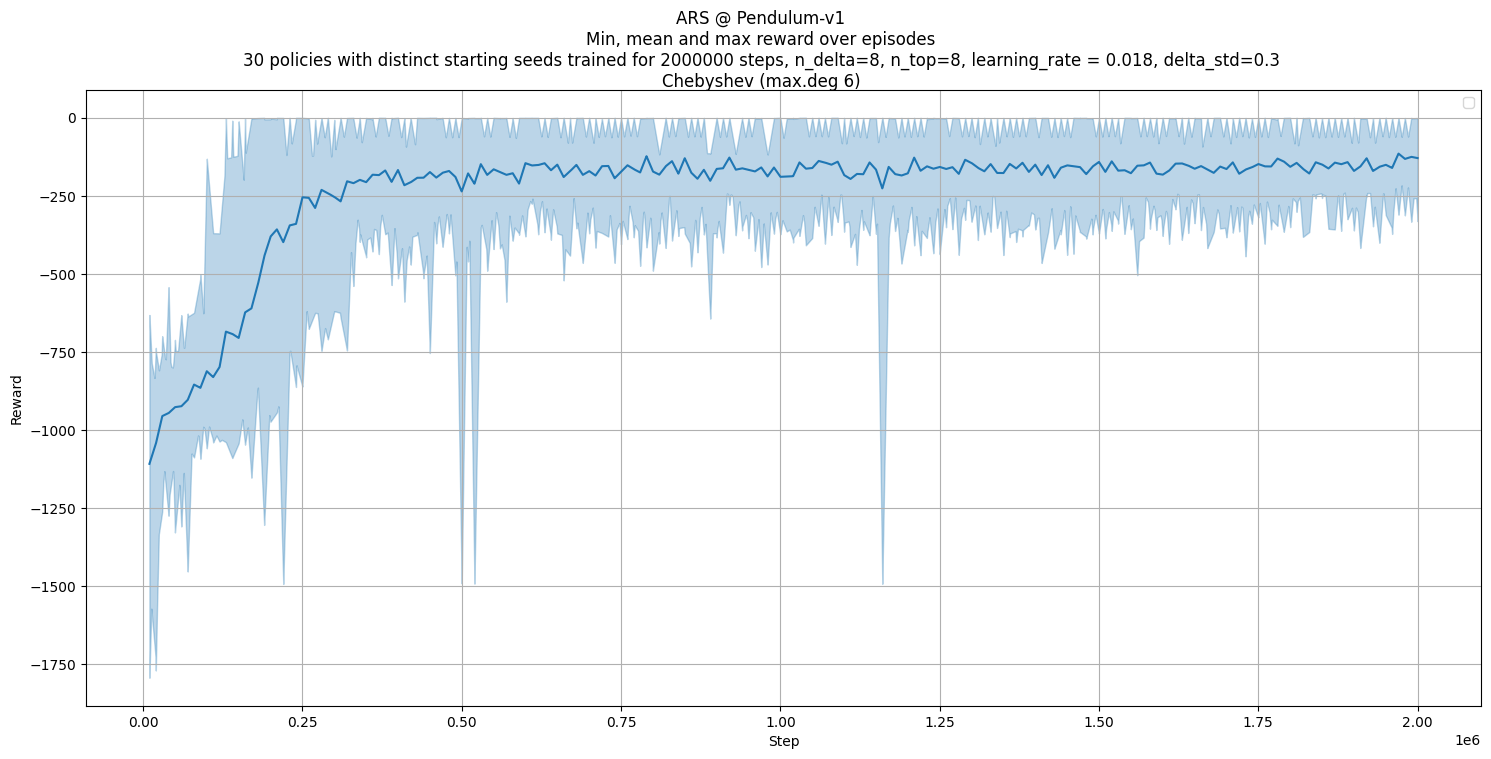

In [16]:
plot_training_reward(log_dir_29, num_policies, name_prefix_chebyshev, seed, title=f'ARS @ {env_name}\nMin, mean and max reward over episodes\n{num_policies} policies with distinct starting seeds trained for {n_timesteps} steps, n_delta=8, n_top=8, learning_rate = 0.018, delta_std=0.3\nChebyshev (max.deg 6)')

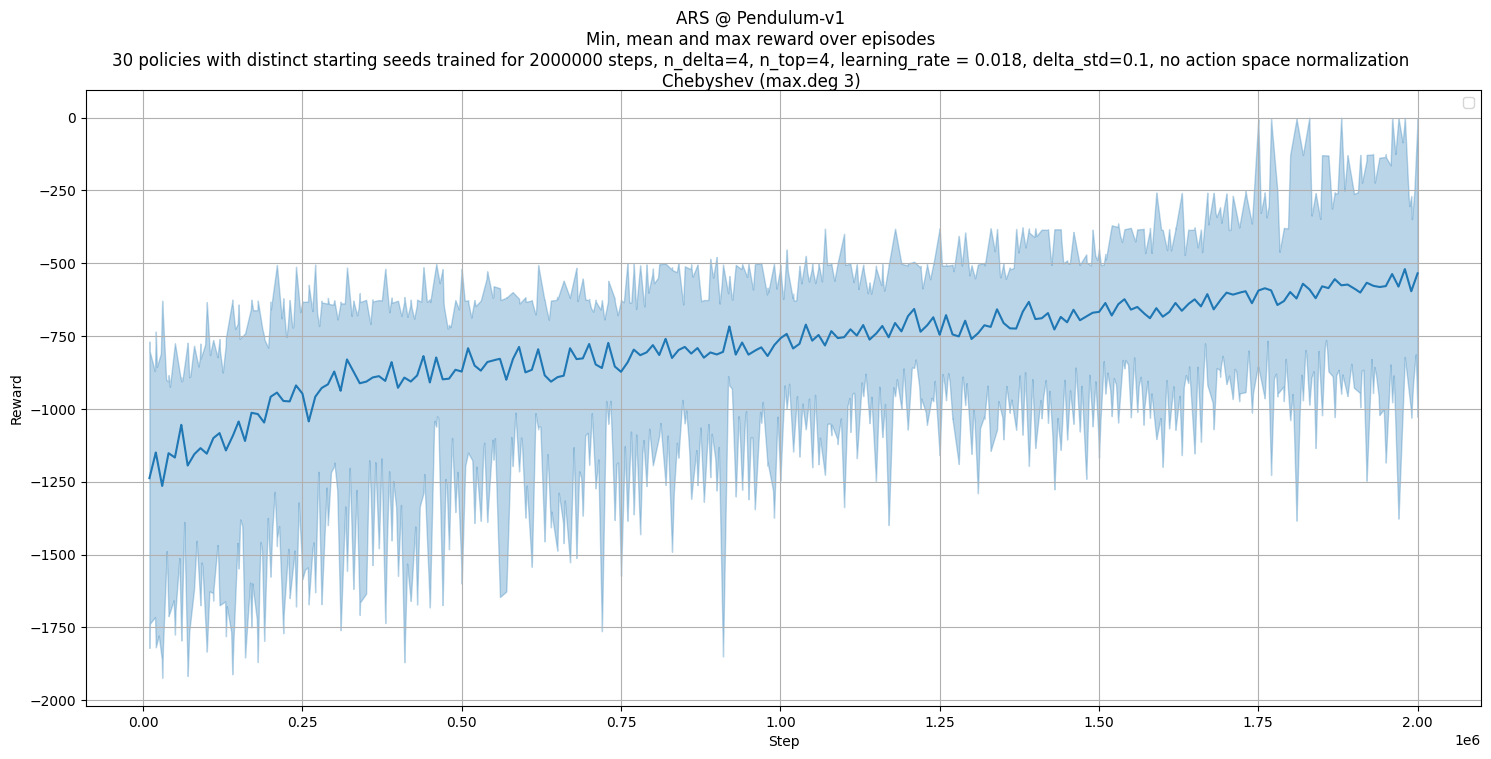

In [15]:
plot_training_reward(log_dir_35, num_policies, name_prefix_chebyshev, seed, title=f'ARS @ {env_name}\nMin, mean and max reward over episodes\n{num_policies} policies with distinct starting seeds trained for {n_timesteps} steps, n_delta=4, n_top=4, learning_rate = 0.018, delta_std=0.1, no action space normalization\nChebyshev (max.deg 3)')

# Evaluation

Since the Pendulum environment does not support setting a deterministic initialization position within the observation space, we have to implement it.  

In [10]:
# Equidistant points for each dimension
n_points_per_dim = 50
angles = np.linspace(-np.pi, np.pi, n_points_per_dim)
velocities = np.linspace(-1, 1, n_points_per_dim)
angle_grid, velocity_grid = np.meshgrid(angles, velocities)
initial_states = np.column_stack([angle_grid.ravel(), velocity_grid.ravel()])

print(f"Total initial states: {len(initial_states)}") 
print(f"First few states:\n{initial_states[:5]}")

Total initial states: 2500
First few states:
[[-3.14159265 -1.        ]
 [-3.01336438 -1.        ]
 [-2.88513611 -1.        ]
 [-2.75690784 -1.        ]
 [-2.62867957 -1.        ]]


In [ ]:
options={'x_init': -1.0, 'y_init': -1.0}

# Chebyshev env with normalization
model, env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=deterministic_pendulum_env_name, algo='ars')
env.venv.envs[0].reset(options=options)

As expected, since the theta dot axis [-8, 8] is normed to [-1, 1], a value of -1 will lead to -0.125. 
cos(-1), sin(-1) produce the expected result.

In [ ]:
# Huggingface env without normalization
sac_model, sac_env = parallel.get_rl_zoo3_model_and_generate_env('ppo', 'rl-trained-agents', 'Pendulum-v1')

# Non-clean way of working around non-deterministic initialization, replace innermost env
sac_env.envs[0].env.env.env.env = custom_gymnasium.DeterministicPendulumEnv()
sac_env.envs[0].env.env.env.env.reset(options=options)

cos(-1), sin(-1) and theta dot produce the expected result.

## Collect data

In [ ]:
start = time.time()
db['pendulum_chebyshev_ars_eval_results_20251112_4'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_4'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_3'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_3'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_2'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_2'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_1'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_1'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 40006 seconds

In [ ]:
start = time.time()
db['pendulum_chebyshev_ars_eval_results_20251112_5'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_5'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 10869 seconds

In [ ]:
start = time.time()
db['pendulum_chebyshev_ars_eval_results_20251112_7'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_7'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 10433 seconds

In [ ]:
start = time.time()
db['pendulum_chebyshev_ars_eval_results_20251112_6'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_6'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_8'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_8'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_9'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_9'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_10'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_10'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_11'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_11'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_12'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_12'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_13'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_13'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_14'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_14'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_15'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_15'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_16'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_16'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
db['pendulum_chebyshev_ars_eval_results_20251112_17'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_17'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 153345 seconds

In [ ]:
start = time.time()
db['pendulum_chebyshev_ars_eval_results_20251112_18'] = exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states(chebyshev_results=db['pendulum_sb3_chebyshev_ars_20251112_18'], initial_states=initial_states, env_name=deterministic_pendulum_env_name)
print(f'Execution took {time.time()-start:.0f} seconds')

In [ ]:
coeffs = db['pendulum_sb3_chebyshev_ars_20251112_18']
coeffs = [row[2] for row in coeffs]

start = time.time()
pool = parallel.NestablePool(mp.cpu_count()-1)
db['pendulum_chebyshev_ars_eval_results_20251112_18'] = pool.starmap(exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states_single_coeffs, zip(coeffs, repeat(initial_states)))
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 3880 seconds

In [ ]:
start = time.time()
numcores = mp.cpu_count()-1
db['pendulum_chebyshev_ars_eval_results_20251112_19'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_19'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_20'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_20'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_21'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_21'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_22'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_22'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_23'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_23'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_24'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_24'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_25'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_25'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_26'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_26'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_27'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_27'], initial_states=initial_states, numcores=numcores)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 30241 seconds

In [ ]:
start = time.time()
numcores = mp.cpu_count()-1
db['pendulum_chebyshev_ars_eval_results_20251112_28'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_28'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_29'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_29'], initial_states=initial_states, numcores=numcores)
db['pendulum_chebyshev_ars_eval_results_20251112_30'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_30'], initial_states=initial_states, numcores=numcores)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 9079 seconds

In [ ]:
start = time.time()
numcores = mp.cpu_count()-1
db['pendulum_chebyshev_ars_eval_results_20251112_31'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_31'], initial_states=initial_states, numcores=numcores, action_space_normalization=False)
db['pendulum_chebyshev_ars_eval_results_20251112_32'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_32'], initial_states=initial_states, numcores=numcores, action_space_normalization=False)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 4417 seconds

In [ ]:
start = time.time()
numcores = mp.cpu_count()-1
db['pendulum_chebyshev_ars_eval_results_20251112_34'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_34'], initial_states=initial_states, numcores=numcores, action_space_normalization=False)
db['pendulum_chebyshev_ars_eval_results_20251112_35'] = run_chebyshev_ars_evaluation(results=db['pendulum_sb3_chebyshev_ars_20251112_35'], initial_states=initial_states, numcores=numcores, action_space_normalization=False)
print(f'Execution took {time.time()-start:.0f} seconds')

Execution took 2290 seconds

## Evaluate data

In [43]:
# n_delta = 4 
# n_top = 1
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_1']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_1']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251112_1632_1_709918 -240.9707  0       
2      pendulum_ch-ars__20251112_1711_47_815743 -284.0902  0       
3      pendulum_ch-ars__20251112_1632_1_712427 -301.5143  0       
4      pendulum_ch-ars__20251112_1751_41_011427 -302.3360  0       
5      pendulum_ch-ars__20251112_1632_1_713464 -322.5100  0       

            Combined Mean Reward of Top Results             
Mean reward: -290.2842


In [44]:
# n_delta = 4 
# n_top = 2
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_2']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_2']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251112_1448_46_149911 -155.8260  0       
2      pendulum_ch-ars__20251112_1528_14_455815 -170.8620  0       
3      pendulum_ch-ars__20251112_1528_11_759894 -174.2869  0       
4      pendulum_ch-ars__20251112_1528_16_671465 -174.6545  0       
5      pendulum_ch-ars__20251112_1448_46_152352 -175.3709  0       

            Combined Mean Reward of Top Results             
Mean reward: -170.2000


In [45]:
# n_delta = 4 
# n_top = 3
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_3']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_3']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251112_1305_27_453566 -154.7303  0       
2      pendulum_ch-ars__20251112_1345_10_634605 -158.2119  0       
3      pendulum_ch-ars__20251112_1305_27_445607 -163.4765  0       
4      pendulum_ch-ars__20251112_1424_53_212374 -165.6136  0       
5      pendulum_ch-ars__20251112_1305_27_432202 -166.1584  0       

            Combined Mean Reward of Top Results             
Mean reward: -161.6381


In [46]:
# n_delta = 4 
# n_top = 4
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_4']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_4']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251112_1121_52_049324 -154.2231  0       
2      pendulum_ch-ars__20251112_1121_52_042978 -156.5847  0       
3      pendulum_ch-ars__20251112_1121_52_024231 -157.8278  0       
4      pendulum_ch-ars__20251112_1241_26_439618 -159.5142  0       
5      pendulum_ch-ars__20251112_1121_52_045543 -160.0593  0       

            Combined Mean Reward of Top Results             
Mean reward: -157.6418


In [47]:
# n_delta = 5
# n_top = 5
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_5']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_5']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251113_0907_55_790661 -157.7871  0       
2      pendulum_ch-ars__20251113_0825_17_961107 -158.0327  0       
3      pendulum_ch-ars__20251113_0825_17_957000 -158.4305  0       
4      pendulum_ch-ars__20251113_0825_17_952213 -159.1101  0       
5      pendulum_ch-ars__20251113_0907_54_918661 -160.2105  0       

            Combined Mean Reward of Top Results             
Mean reward: -158.7142


In [48]:
# kwargs_ars['n_delta'] = 4
# kwargs_ars['n_top'] = None
# kwargs_ars['learning_rate'] = 0.03
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_6']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_6']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251113_1354_13_383516 -151.8718  0       
2      pendulum_ch-ars__20251113_1354_13_381703 -156.0818  0       
3      pendulum_ch-ars__20251113_1434_21_860694 -159.8288  0       
4      pendulum_ch-ars__20251113_1354_13_381646 -162.1448  0       
5      pendulum_ch-ars__20251113_1515_3_791015 -162.4295  0       

            Combined Mean Reward of Top Results             
Mean reward: -158.4714


In [49]:
# kwargs_ars['learning_rate'] = 0.005
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_7']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_7']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251113_1539_30_409315 -166.5614  0       
2      pendulum_ch-ars__20251113_1619_55_318775 -166.8916  0       
3      pendulum_ch-ars__20251113_1539_30_419262 -167.2561  0       
4      pendulum_ch-ars__20251113_1539_30_423991 -167.6600  0       
5      pendulum_ch-ars__20251113_1619_53_007709 -169.3923  0       

            Combined Mean Reward of Top Results             
Mean reward: -167.5523


In [50]:
# kwargs_ars['learning_rate'] = 0.018
# kwargs_ars['degree'] = 4
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_8']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_8']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251113_1815_22_330925 -154.9898  0       
2      pendulum_ch-ars__20251113_1815_17_293289 -155.7484  0       
3      pendulum_ch-ars__20251113_1815_20_346909 -156.3612  0       
4      pendulum_ch-ars__20251113_1725_31_387448 -159.3396  0       
5      pendulum_ch-ars__20251113_1725_31_400053 -159.6010  0       

            Combined Mean Reward of Top Results             
Mean reward: -157.2080


In [51]:
# kwargs_ars['degree'] = 6
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_9']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_9']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251113_2055_33_647333 -155.0486  0       
2      pendulum_ch-ars__20251113_1935_51_876182 -155.2999  0       
3      pendulum_ch-ars__20251113_2216_15_124188 -156.2472  0       
4      pendulum_ch-ars__20251113_2216_10_411557 -160.7211  0       
5      pendulum_ch-ars__20251113_2055_9_767804 -161.1853  0       

            Combined Mean Reward of Top Results             
Mean reward: -157.7004


In [52]:
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.05
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_10']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_10']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251114_1223_28_361139 -167.0130  0       
2      pendulum_ch-ars__20251114_1223_28_359935 -167.8353  0       
3      pendulum_ch-ars__20251114_1303_5_394425 -168.7560  0       
4      pendulum_ch-ars__20251114_1342_38_317652 -172.9378  0       
5      pendulum_ch-ars__20251114_1303_10_466118 -173.5690  0       

            Combined Mean Reward of Top Results             
Mean reward: -170.0222


In [53]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.05
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_11']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_11']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251114_1406_21_957444 -164.9284  0       
2      pendulum_ch-ars__20251114_1523_25_414780 -171.8281  0       
3      pendulum_ch-ars__20251114_1406_21_975890 -181.7808  0       
4      pendulum_ch-ars__20251114_1523_32_465726 -182.9365  0       
5      pendulum_ch-ars__20251114_1523_30_453792 -184.4490  0       

            Combined Mean Reward of Top Results             
Mean reward: -177.1845


In [54]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.05
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = 4
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_12']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_12']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251114_1725_9_446198 -192.9830  0       
2      pendulum_ch-ars__20251114_1841_57_956322 -194.4326  0       
3      pendulum_ch-ars__20251114_1725_9_444225 -212.8085  0       
4      pendulum_ch-ars__20251114_1842_6_605666 -228.7757  0       
5      pendulum_ch-ars__20251114_1725_9_446018 -232.0372  0       

            Combined Mean Reward of Top Results             
Mean reward: -212.2074


In [55]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = 4
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_13']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_13']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251114_2042_33_313359 -165.1544  0       
2      pendulum_ch-ars__20251114_2316_40_891069 -168.0854  0       
3      pendulum_ch-ars__20251114_2042_33_329549 -178.1691  0       
4      pendulum_ch-ars__20251114_2159_5_176478 -180.2662  0       
5      pendulum_ch-ars__20251114_2316_57_688614 -187.1739  0       

            Combined Mean Reward of Top Results             
Mean reward: -175.7698


In [56]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_14']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_14']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251115_0117_19_372603 -152.2495  0       
2      pendulum_ch-ars__20251115_0235_16_416377 -152.3629  0       
3      pendulum_ch-ars__20251115_0235_16_218338 -153.5801  0       
4      pendulum_ch-ars__20251115_0235_18_443149 -154.2307  0       
5      pendulum_ch-ars__20251115_0000_20_221017 -154.4853  0       

            Combined Mean Reward of Top Results             
Mean reward: -153.3817


In [57]:
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.05
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = 4
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_15']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_15']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251115_0318_56_892096 -173.8623  0       
2      pendulum_ch-ars__20251115_0357_50_293556 -179.0926  0       
3      pendulum_ch-ars__20251115_0357_49_390389 -179.5201  0       
4      pendulum_ch-ars__20251115_0318_56_893453 -188.0841  0       
5      pendulum_ch-ars__20251115_0318_56_891085 -188.9409  0       

            Combined Mean Reward of Top Results             
Mean reward: -181.9000


In [58]:
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = 4
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_16']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_16']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251115_0618_41_049879 -164.0578  0       
2      pendulum_ch-ars__20251115_0500_35_772351 -164.3982  0       
3      pendulum_ch-ars__20251115_0500_35_760351 -165.7741  0       
4      pendulum_ch-ars__20251115_0539_41_817047 -167.4051  0       
5      pendulum_ch-ars__20251115_0500_35_772782 -171.3712  0       

            Combined Mean Reward of Top Results             
Mean reward: -166.6013


In [59]:
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_17']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_17']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251115_0642_22_479013 -157.5333  0       
2      pendulum_ch-ars__20251115_0721_22_131972 -158.7034  0       
3      pendulum_ch-ars__20251115_0642_22_492128 -160.2348  0       
4      pendulum_ch-ars__20251115_0721_28_356212 -161.0995  0       
5      pendulum_ch-ars__20251115_0642_22_501587 -162.0187  0       

            Combined Mean Reward of Top Results             
Mean reward: -159.9179


Insights:
 - Reducing 'delta_std' (below 0.1) reduces performance
 - Reducing 'n_top' reduces performance
 - Reducing learning rate from 0.018 reduces performance
 - The best result so far was achieved with increased learning rate from 0.018 to 0.3 with degree 3 (-151.8718). The top 5 of that experiment have a combined mean reward of -158.4714.
 - The best combined top 5 group mean reward was achieved by the experiment using degree 6 and n_delta = n_top = 8 (-153.3817, the best individual result of that group lies at -152.2495)
 - For degree 3, increasing n_delta = n_top to greater than 4 reduces performance, while for degree 6 performance is significantly increased

 Next:
 Perform degree 6 experiments:
  - How does increasing learning rate affect performance?
  - How does increasing n_delta = n_top affect performance?
  - How does increasing delta_std affect performance?
  - How does further increasing the degree to 8 affect performance?

In [28]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
# kwargs_ars['learning_rate'] = 0.03
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_18']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_18']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251117_1051_37_856929 -154.6171  0       
2      pendulum_ch-ars__20251117_1224_51_126042 -154.6839  0       
3      pendulum_ch-ars__20251117_1224_29_079317 -154.9274  0       
4      pendulum_ch-ars__20251117_1051_28_243118 -154.9301  0       
5      pendulum_ch-ars__20251117_1225_9_128981 -157.5288  0       

            Combined Mean Reward of Top Results             
Mean reward: -155.3374


In [19]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 12
# kwargs_ars['n_top'] = None
# kwargs_ars['learning_rate'] = 0.018
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_19']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_19']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251117_2003_17_724726 -152.3138  0       
2      pendulum_ch-ars__20251117_1730_8_905093 -152.8204  0       
3      pendulum_ch-ars__20251117_1730_8_904983 -153.0396  0       
4      pendulum_ch-ars__20251117_1730_8_910849 -153.5479  0       
5      pendulum_ch-ars__20251117_1846_47_223637 -153.5591  0       

            Combined Mean Reward of Top Results             
Mean reward: -153.0562


In [20]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.15
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_20']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_20']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251117_2047_33_618340 -151.3320  0       
2      pendulum_ch-ars__20251117_2204_1_722617 -151.5522  0       
3      pendulum_ch-ars__20251117_2321_3_252265 -152.1484  0       
4      pendulum_ch-ars__20251117_2204_3_335186 -152.6719  0       
5      pendulum_ch-ars__20251117_2321_23_044500 -153.5053  0       

            Combined Mean Reward of Top Results             
Mean reward: -152.2420


In [21]:
# kwargs_ars['degree'] = 8
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_21']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_21']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_0004_41_129667 -157.0197  0       
2      pendulum_ch-ars__20251118_0208_39_732534 -160.3066  0       
3      pendulum_ch-ars__20251118_0208_49_441296 -161.6954  0       
4      pendulum_ch-ars__20251118_0414_20_676004 -162.9574  0       
5      pendulum_ch-ars__20251118_0004_41_140969 -163.5130  0       

            Combined Mean Reward of Top Results             
Mean reward: -161.0984


In [22]:
# kwargs_ars['degree'] = 8
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['n_delta'] = 12
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_22']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_22']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_0728_44_570595 -153.5193  0       
2      pendulum_ch-ars__20251118_0524_7_252485 -153.7734  0       
3      pendulum_ch-ars__20251118_0524_7_241441 -155.2776  0       
4      pendulum_ch-ars__20251118_0729_8_834946 -155.3980  0       
5      pendulum_ch-ars__20251118_0524_7_242251 -155.5903  0       

            Combined Mean Reward of Top Results             
Mean reward: -154.7117


In [23]:
# kwargs_ars['degree'] = 8
# kwargs_ars['delta_std'] = 0.15
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_23']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_23']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_1249_14_830412 -155.1485  0       
2      pendulum_ch-ars__20251118_1249_17_925758 -155.4440  0       
3      pendulum_ch-ars__20251118_1044_44_943823 -155.8679  0       
4      pendulum_ch-ars__20251118_1455_22_429677 -156.0034  0       
5      pendulum_ch-ars__20251118_1044_44_941507 -156.0458  0       

            Combined Mean Reward of Top Results             
Mean reward: -155.7019


In [24]:
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.15
# kwargs_ars['n_delta'] = 4
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_24']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_24']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_1605_21_292410 -152.6590  0       
2      pendulum_ch-ars__20251118_1644_51_076642 -155.0508  0       
3      pendulum_ch-ars__20251118_1605_21_285742 -155.4393  0       
4      pendulum_ch-ars__20251118_1644_49_776860 -156.1387  0       
5      pendulum_ch-ars__20251118_1644_47_717171 -156.4142  0       

            Combined Mean Reward of Top Results             
Mean reward: -155.1404


In [25]:
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['steps'] = 1500000
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_25']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_25']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_1818_24_586582 -157.9814  0       
2      pendulum_ch-ars__20251118_1748_56_132721 -158.4669  0       
3      pendulum_ch-ars__20251118_1748_56_131023 -160.3865  0       
4      pendulum_ch-ars__20251118_1818_22_386063 -161.4429  0       
5      pendulum_ch-ars__20251118_1748_56_127651 -162.0079  0       

            Combined Mean Reward of Top Results             
Mean reward: -160.0571


In [26]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['steps'] = 1500000
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_26']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_26']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_1906_20_845999 -153.2312  0       
2      pendulum_ch-ars__20251118_1906_20_840771 -153.5674  0       
3      pendulum_ch-ars__20251118_2102_28_769963 -153.9386  0       
4      pendulum_ch-ars__20251118_1906_20_836562 -154.7175  0       
5      pendulum_ch-ars__20251118_2004_15_721895 -155.3127  0       

            Combined Mean Reward of Top Results             
Mean reward: -154.1535


In [27]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['steps'] = 3000000
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_27']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_27']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251118_2135_34_484815 -151.0539  0       
2      pendulum_ch-ars__20251119_0129_30_832264 -152.5703  0       
3      pendulum_ch-ars__20251118_2135_34_483670 -152.7467  0       
4      pendulum_ch-ars__20251118_2135_34_486904 -153.3680  0       
5      pendulum_ch-ars__20251118_2331_44_350580 -153.9438  0       

            Combined Mean Reward of Top Results             
Mean reward: -152.7365


Insights:  
- Increasing learning rate reduces overall performance.  
- Increasing the degree to 8 does not increase performance. The current data suggests degree 6 as the best option.  
- With degree 6, increasing n_delta = n_top from 8 to 12 does not further increase performance significantly.  
- With degree 8, performance is better using n_delta = n_top 12 instead of 8. This suggests that higher degrees benefit from higher n_delta = n_top.   
- Increasing delta_std from 0.1 to 0.15 increases performance slightly.  
- Increasing number of steps from 2M to 3M for learning does not increase overall performance, while reducing them to 1M5 reduces performance

Next: Perform degree 6 experiments with increased delta_std parameter

In [12]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.2
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_28']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_28']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251119_1818_40_126177 -150.9182  0       
2      pendulum_ch-ars__20251119_1701_39_344385 -150.9686  0       
3      pendulum_ch-ars__20251119_1701_39_339898 -151.4694  0       
4      pendulum_ch-ars__20251119_1701_39_341197 -152.0811  0       
5      pendulum_ch-ars__20251119_1701_39_342595 -152.1933  0       

            Combined Mean Reward of Top Results             
Mean reward: -151.5261


In [13]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.3
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_29']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_29']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251119_2254_18_977507 -150.7964  0       
2      pendulum_ch-ars__20251119_2254_11_497275 -152.2361  0       
3      pendulum_ch-ars__20251119_2019_41_526932 -152.3370  0       
4      pendulum_ch-ars__20251119_2136_47_995374 -152.3534  0       
5      pendulum_ch-ars__20251119_2019_41_536933 -152.3663  0       

            Combined Mean Reward of Top Results             
Mean reward: -152.0178


In [14]:
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.5
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_30']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_30']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251119_2338_7_325873 -151.3787  0       
2      pendulum_ch-ars__20251120_0055_31_419786 -151.4834  0       
3      pendulum_ch-ars__20251120_0055_37_762033 -151.7778  0       
4      pendulum_ch-ars__20251119_2338_7_344783 -151.9460  0       
5      pendulum_ch-ars__20251120_0213_32_645243 -152.0287  0       

            Combined Mean Reward of Top Results             
Mean reward: -151.7229


A little improvement by increasing delta_std from 0.15, increasing delta_std to higher than 0.3 reduces performance.  
Last test:  
Since SOTA SAC has no action space normalization, how does not normalize actions perform with CH-ARS?  

In [14]:
# kwargs_ars['normalize_actions'] = False
# kwargs_ars['degree'] = 6
# kwargs_ars['delta_std'] = 0.2
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 8
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_31']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_31']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251120_1654_22_696474 -153.1651  0       
2      pendulum_ch-ars__20251120_1806_43_908733 -153.6056  0       
3      pendulum_ch-ars__20251120_1922_43_355940 -155.0690  0       
4      pendulum_ch-ars__20251120_1922_37_463430 -155.3141  0       
5      pendulum_ch-ars__20251120_1654_22_697975 -155.5379  0       

            Combined Mean Reward of Top Results             
Mean reward: -154.5384


In [15]:
# kwargs_ars['normalize_actions'] = False
# kwargs_ars['degree'] = 3
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 4
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_32']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_32']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251120_2045_3_852966 -167.6759  0       
2      pendulum_ch-ars__20251120_2006_4_496522 -168.6177  0       
3      pendulum_ch-ars__20251120_2006_4_496369 -169.9641  0       
4      pendulum_ch-ars__20251120_2045_5_890650 -171.9814  0       
5      pendulum_ch-ars__20251120_2006_4_481781 -172.4693  0       

            Combined Mean Reward of Top Results             
Mean reward: -170.1417


Unnormalized actions do not improve performance but lower it.  

In [19]:
# kwargs_ars['normalize_actions'] = False
# kwargs_ars['degree'] = 2
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 4
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_34']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_34']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251121_1453_26_282794 -506.3543  0       
2      pendulum_ch-ars__20251121_1348_48_128620 -516.2809  0       
3      pendulum_ch-ars__20251121_1348_48_137949 -530.8013  0       
4      pendulum_ch-ars__20251121_1453_22_733461 -552.3157  0       
5      pendulum_ch-ars__20251121_1348_48_138015 -563.7886  0       

            Combined Mean Reward of Top Results             
Mean reward: -533.9082


In [20]:
# kwargs_ars['normalize_actions'] = False
# kwargs_ars['degree'] = 1
# kwargs_ars['delta_std'] = 0.1
# kwargs_ars['steps'] = 2000000
# kwargs_ars['n_delta'] = 4
# kwargs_ars['n_top'] = None
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_35']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_35']
chebyshev_eval_results = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in chebyshev_eval_results]
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ars__20251121_1540_31_472581 -715.9089  0       
2      pendulum_ch-ars__20251121_1607_49_395036 -746.4595  0       
3      pendulum_ch-ars__20251121_1513_31_354359 -758.8025  0       
4      pendulum_ch-ars__20251121_1513_31_351276 -771.1389  0       
5      pendulum_ch-ars__20251121_1540_36_435063 -795.8346  0       

            Combined Mean Reward of Top Results             
Mean reward: -757.6289


Reducing the degree lowers performance

## Try best agent

In [ ]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_29']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_29']
col_0_values = [row[0] for row in chebyshev_eval_results]
best_agent_index = col_0_values.index(max(col_0_values))
best_agent_coeffs = chebyshev_training_results[best_agent_index][-1]

In [38]:
model, env = exp_run.get_sb3_polynomial_model_and_eval_env(algo='ars', coeffs=best_agent_coeffs, env_name=env_name, render=True)
exp_run.run_sb3_model(model, env, render=True)

Using cpu device


(-0.8533567, 0.0)

## Compare to SOTA

We again take the set of pretrained RL Baselines3 Zoo agents ARS, SAC, PPO, DDPG, TD3, A2C and TRPO
trained on the Pendulum environment and compare performance. 

In [20]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ars_20251112_29']
chebyshev_eval_results = db['pendulum_chebyshev_ars_eval_results_20251112_29']
col_0_values = [row[0] for row in chebyshev_eval_results]
best_agent_index = col_0_values.index(max(col_0_values))
best_agent_coeffs = chebyshev_training_results[best_agent_index][-1]

In [ ]:
# How do we implement deterministic starting position env into existing agents?
model, env = parallel.get_rl_zoo3_model_and_generate_env('ppo', 'rl-trained-agents', 'Pendulum-v1')
# Non-clean way of working around non-deterministic initialization
env.envs[0].env.env.env.env = custom_gymnasium.DeterministicPendulumEnv() # ... by replacing the wrapped env / behaves exactly the same except for the reset and is then wrapped by existing normalization wrappers etc. of the huggingface model
env.reset()
obs = np.array([env.envs[0].env.env.env.env.reset(options=options)[0]])
obs

In [31]:
from itertools import product
algos = ['ppo', 'tqc', 'sac', 'td3', 'trpo', 'a2c', 'ddpg', 'ars']

param_combinations = list(product(algos, initial_states))
params = []

for p in param_combinations:
    params.append({'algo': p[0], 'start_loc': p[1]})

In [ ]:
results = []

for p in params:
    results.append(parallel.job_get_episode_reward_rl_zoo3_model_pendulum_deterministic_start(p))

db['huggingface_evaluation_results_pendulum_20251110'] = results

Experiment ran 46 minutes.

In [79]:
rlzoo_rewards = summarize_rewards(results)

In [19]:
results = db['huggingface_evaluation_results_pendulum_20251110']
results_chebyshev_ars = db['pendulum_chebyshev_ars_eval_results_20251112_29']
results_chebyshev_ars = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in results_chebyshev_ars]

rlzoo_rewards = summarize_rewards(results)

chebyshev_ars_episode_reward = [results_chebyshev_ars[best_agent_index][2], results_chebyshev_ars[best_agent_index][0], results_chebyshev_ars[best_agent_index][-1]]
ars_episode_reward = [rlzoo_rewards['ars']['min'], rlzoo_rewards['ars']['mean'], rlzoo_rewards['ars']['max']]
ddpg_episode_reward = [rlzoo_rewards['ddpg']['min'], rlzoo_rewards['ddpg']['mean'], rlzoo_rewards['ddpg']['max']]
a2c_episode_reward = [rlzoo_rewards['a2c']['min'], rlzoo_rewards['a2c']['mean'], rlzoo_rewards['a2c']['max']]
trpo_episode_reward = [rlzoo_rewards['trpo']['min'], rlzoo_rewards['trpo']['mean'], rlzoo_rewards['trpo']['max']]
td3_episode_reward = [rlzoo_rewards['td3']['min'], rlzoo_rewards['td3']['mean'], rlzoo_rewards['td3']['max']]
sac_episode_reward = [rlzoo_rewards['sac']['min'], rlzoo_rewards['sac']['mean'], rlzoo_rewards['sac']['max']]
tqc_episode_reward = [rlzoo_rewards['tqc']['min'], rlzoo_rewards['tqc']['mean'], rlzoo_rewards['tqc']['max']]
ppo_episode_reward = [rlzoo_rewards['ppo']['min'], rlzoo_rewards['ppo']['mean'], rlzoo_rewards['ppo']['max']]

data = {'ars': ars_episode_reward, 'ddpg': ddpg_episode_reward, 'a2c': a2c_episode_reward, 'trpo': trpo_episode_reward, 'td3': td3_episode_reward, 'sac': sac_episode_reward, 'tqc': tqc_episode_reward, 'ppo': ppo_episode_reward, 'ch-6-ars': chebyshev_ars_episode_reward}
sorted_data = dict(sorted(data.items(), key=lambda item: item[1][1], reverse=True)) # sort by mean reward

Text(0.5, 1.0, 'Min, mean and max episode rewards\n2500 equidistant starting positions over initialization range')

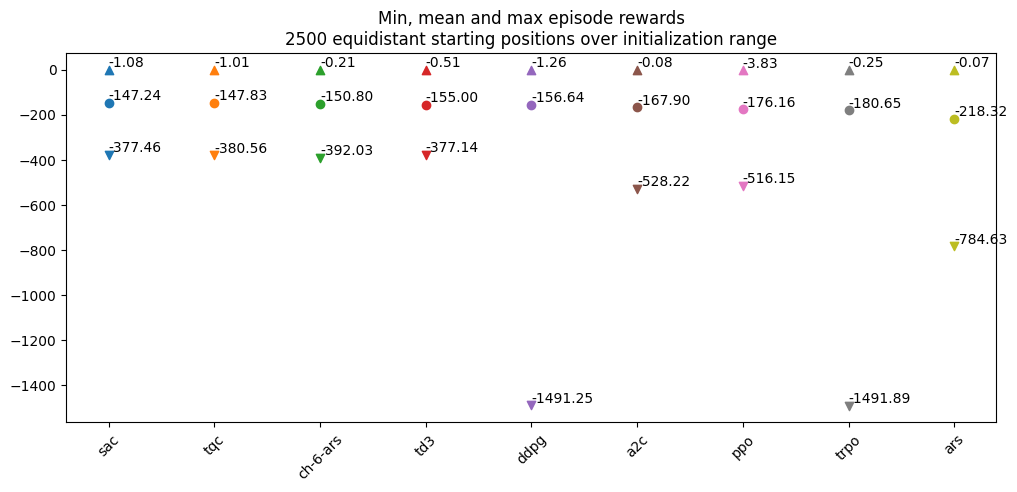

In [20]:
fig, ax1 = plt.subplots()
fig.set_figwidth(12)

# Plt1: Extract names and values
names = list(sorted_data.keys())
values = list(sorted_data.values())

# Create a consistent color mapping for names
unique_names = list(sorted_data.keys())  # Start with names from data1
colors = [plt.cm.tab10(i % 10) for i in range(len(unique_names))]
color_map = {name: colors[i] for i, name in enumerate(unique_names)}

for i, (name, value) in enumerate(sorted_data.items()):
    ax1.scatter(i, value[0], color=color_map[name], label=name, marker='v')
    ax1.scatter(i, value[1], color=color_map[name], label=name, marker='o')
    ax1.scatter(i, value[2], color=color_map[name], label=name, marker='^')
    # Add the value next to the point
    if value[1]:
        ax1.text(i, value[0], f"{value[0]:.2f}", fontsize=10, verticalalignment='bottom')
        ax1.text(i, value[1], f"{value[1]:.2f}", fontsize=10, verticalalignment='bottom')
        ax1.text(i, value[2], f"{value[2]:.2f}", fontsize=10, verticalalignment='bottom')

ax1.set_xticks(range(len(names)), names, fontsize=10, rotation=45)
ax1.set_title(f'Min, mean and max episode rewards\n{n_points_per_dim*n_points_per_dim} equidistant starting positions over initialization range')

Interpretation:
 - The off-policy SOTA SAC agent shows the best mean reward on the Pendulum-v1 environment, tightly followed by the (also off-policy) TQC agent
 - CH-6-ARS comes in third place, followed by the off-policy algorithms TD3 and DDPG
 - All On-policy SOTA agents then follow with quite a gap to the off-policy ones  
 - CH-6-ARS improves performance of the SOTA ARS agent by a large margin, which holds the last place among SOTA agents considering mean reward

 Questions arise:
 - Could a Chebyshev version of SAC even improve performance and beat the MLP version of SAC?
 - Can approximating the SAC agent by a Chebyshev polynomial of max.degree 6 reproduce the performance of MLP SAC?  

### Visualize Reward for individual starting positions

In [38]:
print(f"Total initial states: {len(initial_states)}") 
print(f"First few states:\n{initial_states[:5]}")

Total initial states: 2500
First few states:
[[-3.14159265 -1.        ]
 [-3.01336438 -1.        ]
 [-2.88513611 -1.        ]
 [-2.75690784 -1.        ]
 [-2.62867957 -1.        ]]


In [ ]:
rewards = []
model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=deterministic_pendulum_env_name, coeffs=best_agent_coeffs, algo='ars')
for s in initial_states:
    rewards.append(exp_run.run_sb3_model(model, eval_env, options={'x_init': s[0], 'y_init': s[1]})[0])
db['ch6ars_deterministic_episode_results'] = rewards

Experiment ran for 11 minutes

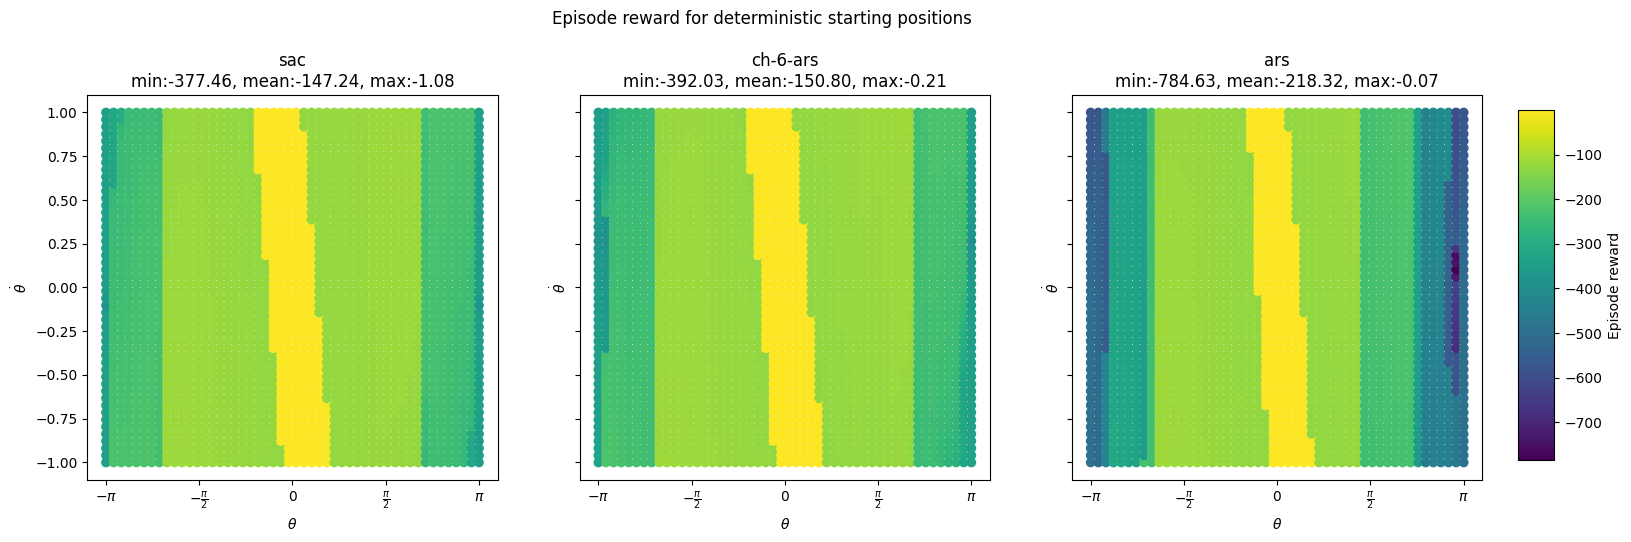

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

x = initial_states[:, 0]
y = initial_states[:, 1]

ch_reward = db['ch6ars_deterministic_episode_results']
results = db['huggingface_evaluation_results_pendulum_20251110']
rewards_by_algo = defaultdict(list)
for algo, _, reward in results:
    rewards_by_algo[algo].append(reward)
sac_reward = rewards_by_algo['sac']
sota_ars_reward = rewards_by_algo['ars']

xticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
xtick_labels = [r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']

vmin = min(min(sac_reward), min(ch_reward), min(sota_ars_reward))
vmax = max(max(sac_reward), max(ch_reward), max(sota_ars_reward))

sc1 = ax1.scatter(x, y, c=sac_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xtick_labels)
ax1.set_title(f'sac\nmin:{min(sac_reward):.2f}, mean:{np.mean(sac_reward):.2f}, max:{max(sac_reward):.2f}')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'$\dot{\theta}$')

sc2 = ax2.scatter(x, y, c=ch_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels)
ax2.set_title(f'ch-6-ars\nmin:{min(ch_reward):.2f}, mean:{np.mean(ch_reward):.2f}, max:{max(ch_reward):.2f}')
ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel(r'$\dot{\theta}$')

sc3 = ax3.scatter(x, y, c=sota_ars_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax3.set_xticks(xticks)
ax3.set_xticklabels(xtick_labels)
ax3.set_title(f'ars\nmin:{min(sota_ars_reward):.2f}, mean:{np.mean(sota_ars_reward):.2f}, max:{max(sota_ars_reward):.2f}')
ax3.set_xlabel(r'$\theta$')
ax3.set_ylabel(r'$\dot{\theta}$')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(sc2, cax=cbar_ax, label='Episode reward')
fig.suptitle('Episode reward for deterministic starting positions', y=1.05)

#plt.tight_layout()
plt.show()

Interpretation:
 - Comparing SAC and CH-6-ARS episode rewards w.r.t starting positions, we see a similar picture in the center, while SAC rewards are better at the outside boundaries
 - Comparing ARS and CH-6-ARS episode rewards w.r.t starting positions, we see that the "center band" is broader with the Chebyshev version and also the outside bands are more favourable

See performance comparison in "Pendulum PPO" notebook.  